# Florence Airbnb – Model Notebook

In this notebook we build and evaluate models to predict Airbnb prices in Florence using the engineered dataset `listings_features.csv`.

We go step by step:

1. **Baseline k‑NN** using only location (latitude & longitude).  
2. **Baseline Gradient Boosting (XGBoost)** using all features.  
3. A **hybrid model** that combines k‑NN spatial information with gradient boosting.

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,  OneHotEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.neighbors import NearestNeighbors
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


data = pd.read_csv('data/listings_features.csv')

In [113]:
model_results = []

## 1. Baseline k‑NN (location only)

We start with a simple baseline: a k‑Nearest Neighbours regressor that uses only latitude and longitude to predict price (log‑transformed). This tells us how much of the price variation can be explained by **location alone**.

### 1.1 Target variable

We predict the nightly price of a listing. Because raw prices are highly right‑skewed, we predict the **log‑transformed price** instead:

\[
y = \log(1 + \text{price})
\]

Using log‑price stabilizes variance and makes errors more comparable between cheap and expensive listings. Predictions are exponentiated back to euros for evaluation and interpretation.

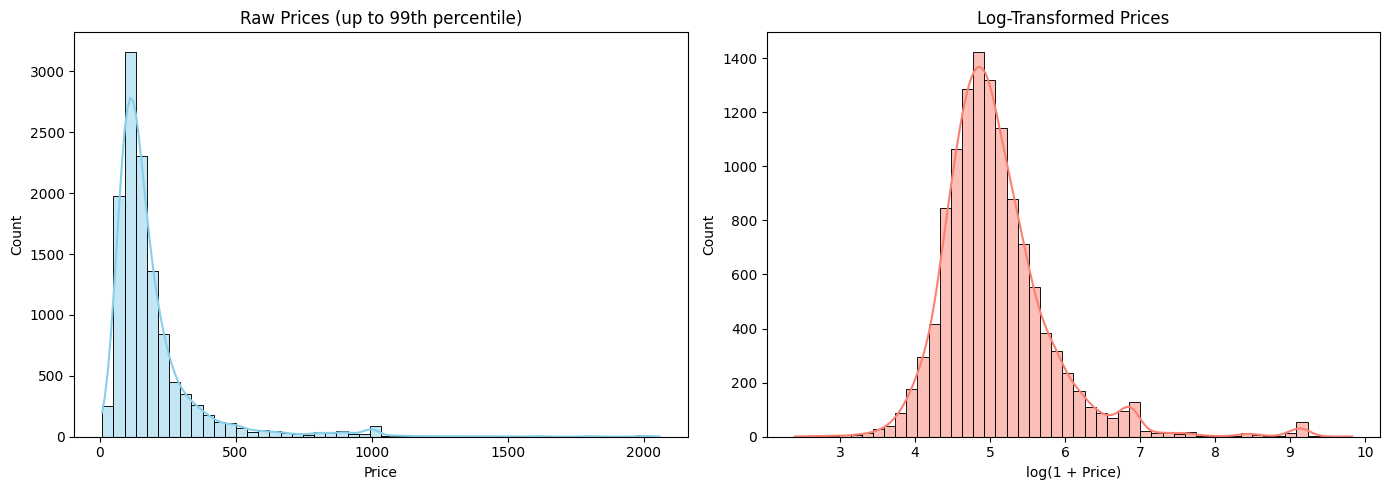

In [114]:
price = data['price']
# log-transform
log_price = np.log1p(price)

upper = price.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(price[price <= upper], bins=50, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Raw Prices (up to 99th percentile)")
axes[0].set_xlabel("Price")

sns.histplot(log_price, bins=50, kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Log-Transformed Prices")
axes[1].set_xlabel("log(1 + Price)")

plt.tight_layout()
plt.show()

The raw Airbnb price distribution is strongly right-skewed, with a long tail of very expensive listings. After applying a log transformation, the distribution becomes more symmetric, which helps stabilize model training and makes prediction errors less dominated by a few extreme prices.

In [115]:
y = log_price

### 1.2 Features for k‑NN

For the k‑NN baseline we use only the listing’s **geographical position**:

- `latitude`  
- `longitude`

These two features are extracted from the cleaned feature table:

- We do **not** include any additional information (beds, amenities, reviews, etc.) here – the point is to see how far we can get with location alone.

In [116]:
X_knn = data[['latitude', 'longitude']].copy()

### 1.3 Model creation 

#### 1.3.1 Choosing the number of neighbours \(k\)

We treat \(k\) as the main hyperparameter of the k‑NN model. To select a good value we:

1. Loop over candidate values \(k = 1, 2, \dots, 40\).  
2. For each \(k\), train a k‑NN regressor on the training set and compute **validation RMSE** on log‑price.  
3. Plot validation RMSE versus \(k\) (elbow plot).  
4. Additionally, plot **training and validation RMSE vs. \(k\)** to visualize the bias–variance trade‑off.

In [117]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_knn, y, test_size=0.2, random_state=42
)

In [118]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)


In [119]:
k_values = range(1, 40)   # you can adjust the range
rmse_scores = []

for k in k_values:
    knn_reg = KNeighborsRegressor(n_neighbors=k, weights='distance')
    knn_reg.fit(X_train_scaled, y_train)
    y_valid_pred_log = knn_reg.predict(X_valid_scaled)

    # Compute RMSE on log-price (or convert back to price if you prefer)
    mse  = mean_squared_error(y_valid, y_valid_pred_log)
    rmse = np.sqrt(mse)
    rmse_scores.append(rmse)

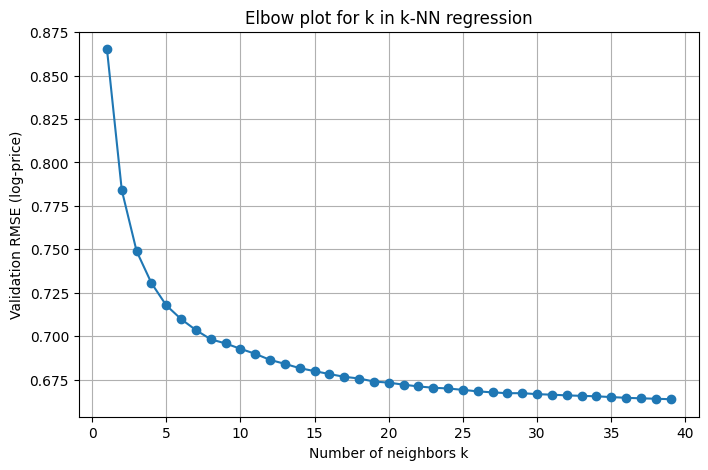

In [120]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, rmse_scores, marker='o')
plt.xlabel("Number of neighbors k")
plt.ylabel("Validation RMSE (log-price)")
plt.title("Elbow plot for k in k-NN regression")
plt.grid(True)
plt.show()

Qualitative observations:

- For very small \(k\) (e.g. 1–2), the model fits the training data extremely well but shows high validation error → high variance / overfitting.  
- As \(k\) increases, validation RMSE drops quickly up to roughly \(k \approx 8–10\), then flattens.  
- For large \(k\), the model becomes a very smooth spatial average; validation RMSE and MAE change only slightly.

From these plots we conclude that any \(k\) in the range **8–12** offers a good trade‑off between bias and variance. For the rest of the analysis we fix **\(k = 10\)** as our final choice, since it lies near the elbow and keeps the notion of a “local neighbourhood” intuitive.

#### 1.3.2 Train / validation / test split and scaling

We split the dataset into three disjoint subsets:

- **Train set** (70 %) – used to fit the k‑NN model and to select hyperparameters.  
- **Validation set** (15 %) – used to tune the number of neighbors \(k\) and to inspect the bias–variance trade‑off.  
- **Test set** (15 %) – held out until the end, used only once to report final performance.

Because k‑NN is distance‑based, we standardize the coordinates:

- Fit a `StandardScaler` on the **training** latitude/longitude.  
- Apply the same transformation to validation and test sets.  

This keeps the distance computation well‑behaved and avoids data leakage from validation/test into training.

In [121]:
# First split: train vs temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_knn, y, test_size=0.3, random_state=42
)

# Second split: temp into valid and test
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# Scale using ONLY train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled  = scaler.transform(X_test)

# Fit k-NN with your chosen k
knn_reg = KNeighborsRegressor(n_neighbors=10, weights='distance')
knn_reg.fit(X_train_scaled, y_train)


,n_neighbors,10
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


#### 1.3.3 Testing

Finaly the Model is tested and evalueted.

In [122]:
# 1. Predict log-prices
y_valid_pred_log = knn_reg.predict(X_valid_scaled)
y_test_pred_log  = knn_reg.predict(X_test_scaled)

# 2. Back to price scale
y_valid_true = np.expm1(y_valid)          # true prices
y_test_true  = np.expm1(y_test)
y_valid_pred = np.expm1(y_valid_pred_log) # predicted prices
y_test_pred  = np.expm1(y_test_pred_log)

# 3. Validation metrics (on price scale)
mse_valid  = mean_squared_error(y_valid_true, y_valid_pred)
rmse_valid = np.sqrt(mse_valid)
mae_valid  = mean_absolute_error(y_valid_true, y_valid_pred)

# 4. Test metrics (on price scale)
mse_test  = mean_squared_error(y_test_true, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test  = mean_absolute_error(y_test_true, y_test_pred)

print("Validation RMSE:", rmse_valid)
print("Validation MAE :", mae_valid)
print("Test RMSE      :", rmse_test)
print("Test MAE       :", mae_test)

Validation RMSE: 708.9211266248509
Validation MAE : 151.8714352745526
Test RMSE      : 937.7637882414587
Test MAE       : 180.78044822234915


In [123]:
model_results.append({
    "name": 'knn_location',
    "description": 'knn with just long and lat, with log prices',
    "rmse_valid": rmse_valid,
    "rmse_test": rmse_test,
    "mae_valid": mae_valid,
    "mae_test": mae_test,
})

Our k‑NN baseline using only geographic coordinates achieves a validation RMSE of about 709 € and MAE of 152 €, and a test RMSE of about 938 € and MAE of 181 €. This indicates that, on average, predictions are off by around 150–180 € per listing, which is relatively large compared to typical Airbnb prices, so we expect more complex models such as gradient boosting to provide substantial improvements.

## 2. Baseline k‑NN (with more features)

In [190]:
num_features = [
    "latitude", "longitude",
    "accommodates", "bathrooms", "bedrooms", "beds",
    "minimum_nights", "maximum_nights",
    "number_of_reviews",
    "description_len_chars", "description_len_words",
    "nb_overview_len_chars", "nb_overview_len_words",
    "amenities_count",
]

bool_features = [
    "review_scores_missing",
    "bathrooms_text_missing",
    "bath_shared",
    "bath_private_flag",
    "bath_half",
    "description_missing",
    "desc_kw_luxury",
    "desc_kw_modern",
    "desc_kw_spacious",
    "desc_kw_cozy",
    "desc_kw_quiet",
    "desc_kw_charming",
    "desc_kw_unforgattable",
    "desc_kw_relaxing",
    "desc_kw_everything you need",
    "desc_kw_cute",
    "desc_kw_comfortable",
    "neighborhood_overview_missing",
    "nb_cat_transport",
    "nb_cat_food_places",
    "nb_cat_shops",
    "nb_cat_sights",
    "nb_cat_nightlife",
    "nb_cat_greenery",
    "nb_cat_quiet_residential",

    # amenity flags (all those you listed)
    "beach_access",
    "shared_bbq_grill",
    "shared_balcony",
    "shared_sauna",
    "skate_ramp",
    "smoking_allowed",
    "sun_loungers",
    "toaster",
    "wine_cellar",
    "wine_glasses",
    "free_resort_access",
    "host_greets_you",
    "paid_resort_access",
    "outdoor_kitchen_any",
    "private_outdoor_kitchen",
    "shared_outdoor_kitchen",
    "hammock",
    "heated_floors",
    "iron",
    "kayak",
    "laser_tag",
    "lockbox",
    "movie_room",
    "microwave",
    "mini_golf",
    "mountain_view",
    "outdoor_dining",
    "outdoor_furniture",
    "outdoor_playground",
    "outdoor_shower",
    "balcony_any",
    "pets_allowed",
    "piano",
    "extra_pillows_blankets",
    "ping_pong",
    "portable_fans",
    "private_entrance",
    "private_living_room",
    "private_balcony",
    "private_sauna",
    "record_player",
    "rice_maker",
    "shades",
    "sauna_any",
    "self_checkIn",
    "private_gym",
    "shared_backyard",
    "shared_gym",
    "hot_water_kettle",
    "hot_water",
    "shared_hot_tub",
    "bathtub",
    "bed_linens",
    "bidet",
    "bikes",
    "blender",
    "board_games",
    "books",
    "bowling_alley",
    "bread_maker",
    "building_staff",
    "smoke_alarm",
    "ceiling_fan",
    "cleaning_products",
    "climbing_wall",
    "clothes_steamer",
    "cook_service",
    "cooking_basics",
    "dining_table",
    "elevator",
    "fire_extinguisher",
    "first_aid",
    "freezer",
    "ac",
    "ice_machine",
    "shared_pool",
    "game_console",
    "children_books",
    "paid_high_chair",
    "fireplace",
    "crib",
    "paid_crib",
    "private_hot_tub",
    "private_bbq_grill",
    "bbq_grill_any",
    "hair_dryer",
    "dryer",
    "heating",
    "hot_tub_any",
    "kitchen",
    "dishwasher",
    "washer",
    "baby_bath",
    "baby_monitor",
    "backyard_any",
    "breakfast",
    "changing_table",
    "charger",
    "paid_dryer",
    "paid_washer",
    "private_backyard",
    "gym_any",
    "tv",
    "wifi",
    "body_soap",
    "shampoo",
    "free_housekeeping",
    "paid_housekeeping",
    "stove",
    "oven",
    "conditioner",
    "refrigerator",
    "sound_system",
    "paid_parking",
    "pool",
    "coffee_maker",
    "free_parking",
    "private_pool",
    "exercise_equipment",
    "clothing_storage",
    "free_high_chair",
    "workspace",
]

cat_features = [
    "neighbourhood_cleansed",
    "property_type",
    "room_type",
]

In [125]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("bool", "passthrough", bool_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)

knn = KNeighborsRegressor(n_neighbors=10, weights="distance")

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("knn", knn),
])

X = data[num_features + bool_features + cat_features]


In [126]:
X = data[num_features + bool_features + cat_features]
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("bool", "passthrough", bool_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)

knn = KNeighborsRegressor(n_neighbors=10, weights="distance")

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("knn", knn),
])

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [127]:
X_train_proc = preprocess.fit_transform(X_train)
X_valid_proc = preprocess.transform(X_valid)

k_values = range(1, 40)
rmse_scores = []

for k in k_values:
    knn_reg = KNeighborsRegressor(n_neighbors=k, weights='distance')
    knn_reg.fit(X_train_proc, y_train)
    y_valid_pred = knn_reg.predict(X_valid_proc)

    mse = mean_squared_error(y_valid, y_valid_pred)
    rmse = np.sqrt(mse)
    rmse_scores.append(rmse)

best_k = k_values[int(np.argmin(rmse_scores))]
print("Best k:", best_k)
print("RMSE at best k:", min(rmse_scores))

Best k: 9
RMSE at best k: 0.5145460059158811


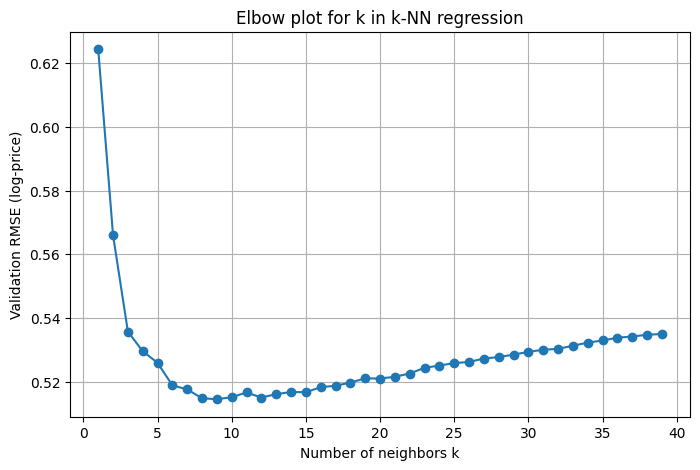

In [128]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, rmse_scores, marker='o')
plt.xlabel("Number of neighbors k")
plt.ylabel("Validation RMSE (log-price)")
plt.title("Elbow plot for k in k-NN regression")
plt.grid(True)
plt.show()

In [129]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Second split: temp into valid and test
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# Scale using ONLY train
X_train_proc = preprocess.fit_transform(X_train)
X_valid_proc = preprocess.transform(X_valid)
X_test_proc = preprocess.transform(X_test)

# Fit k-NN with your chosen k
knn_reg = KNeighborsRegressor(n_neighbors=9, weights='distance')
knn_reg.fit(X_train_proc, y_train)

,n_neighbors,9
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [130]:
# 1. Predict log-prices
y_valid_pred_log = knn_reg.predict(X_valid_proc)
y_test_pred_log  = knn_reg.predict(X_test_proc)

# 2. Back to price scale
y_valid_true = np.expm1(y_valid)          # true prices
y_test_true  = np.expm1(y_test)
y_valid_pred = np.expm1(y_valid_pred_log) # predicted prices
y_test_pred  = np.expm1(y_test_pred_log)

# 3. Validation metrics (on price scale)
mse_valid  = mean_squared_error(y_valid_true, y_valid_pred)
rmse_valid = np.sqrt(mse_valid)
mae_valid  = mean_absolute_error(y_valid_true, y_valid_pred)

# 4. Test metrics (on price scale)
mse_test  = mean_squared_error(y_test_true, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test  = mean_absolute_error(y_test_true, y_test_pred)

print("Validation RMSE:", rmse_valid)
print("Validation MAE :", mae_valid)
print("Test RMSE      :", rmse_test)
print("Test MAE       :", mae_test)

Validation RMSE: 649.2222380191272
Validation MAE : 120.19564009295394
Test RMSE      : 849.7812153210855
Test MAE       : 149.6017707345217


In [131]:
model_results.append({
    "name": 'knn_all',
    "description": 'knn with all features, with log prices',
    "rmse_valid": rmse_valid,
    "rmse_test": rmse_test,
    "mae_valid": mae_valid,
    "mae_test": mae_test,
})

In [191]:
cap_value = data["price"].quantile(0.99)
data_filtered = data[data["price"] <= cap_value].copy()
X = data_filtered[num_features + bool_features + cat_features]
y = data_filtered['price']

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("bool", "passthrough", bool_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)

knn = KNeighborsRegressor(n_neighbors=10, weights="distance")

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("knn", knn),
])

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [192]:
X_train_proc = preprocess.fit_transform(X_train)
X_valid_proc = preprocess.transform(X_valid)

k_values = range(1, 40)
rmse_scores = []

for k in k_values:
    knn_reg = KNeighborsRegressor(n_neighbors=k, weights='distance')
    knn_reg.fit(X_train_proc, y_train)
    y_valid_pred = knn_reg.predict(X_valid_proc)

    mse = mean_squared_error(y_valid, y_valid_pred)
    rmse = np.sqrt(mse)
    rmse_scores.append(rmse)

best_k = k_values[int(np.argmin(rmse_scores))]
print("Best k:", best_k)
print("RMSE at best k:", min(rmse_scores))

Best k: 6
RMSE at best k: 140.2128101762347


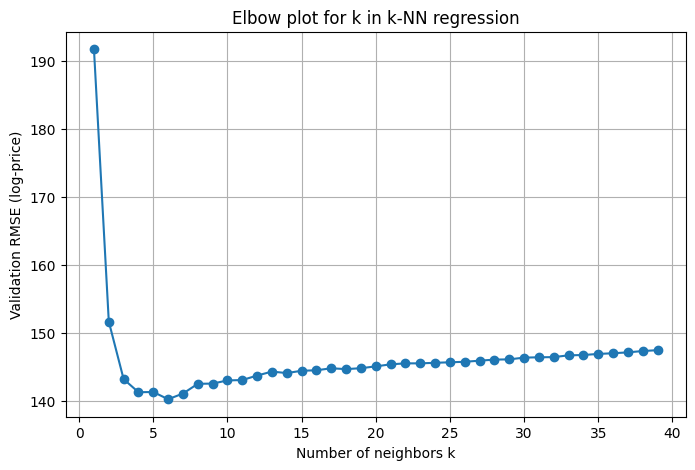

In [193]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, rmse_scores, marker='o')
plt.xlabel("Number of neighbors k")
plt.ylabel("Validation RMSE (log-price)")
plt.title("Elbow plot for k in k-NN regression")
plt.grid(True)
plt.show()

In [194]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Second split: temp into valid and test
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# Scale using ONLY train
X_train_proc = preprocess.fit_transform(X_train)
X_valid_proc = preprocess.transform(X_valid)
X_test_proc = preprocess.transform(X_test)

# Fit k-NN with your chosen k
knn_reg = KNeighborsRegressor(n_neighbors=6, weights='distance')
knn_reg.fit(X_train_proc, y_train)

,n_neighbors,6
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [195]:
y_valid_pred = knn_reg.predict(X_valid_proc)
y_test_pred  = knn_reg.predict(X_test_proc)

# 3. Validation metrics (on price scale)
mse_valid  = mean_squared_error(y_valid, y_valid_pred)
rmse_valid = np.sqrt(mse_valid)
mae_valid  = mean_absolute_error(y_valid, y_valid_pred)

# 4. Test metrics (on price scale)
mse_test  = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test  = mean_absolute_error(y_test, y_test_pred)

print("Validation RMSE:", rmse_valid)
print("Validation MAE :", mae_valid)
print("Test RMSE      :", rmse_test)
print("Test MAE       :", mae_test)

Validation RMSE: 150.46812965064123
Validation MAE : 81.377397584278
Test RMSE      : 139.06058062575693
Test MAE       : 78.0860990381847


In [196]:
model_results.append({
    "name": 'knn_all_filtered',
    "description": 'knn with all features, with filtered prices',
    "rmse_valid": rmse_valid,
    "rmse_test": rmse_test,
    "mae_valid": mae_valid,
    "mae_test": mae_test,
})

## 3. Model Choice: Gradient Boosting

Either XGBoost or Catboost

### Target
Log scaled see above

In [132]:
for col in data.columns:
    print(col)

id
neighbourhood_cleansed
latitude
longitude
property_type
room_type
accommodates
bathrooms
bedrooms
beds
price
minimum_nights
maximum_nights
number_of_reviews
review_scores_rating
review_scores_accuracy
review_scores_cleanliness
review_scores_checkin
review_scores_communication
review_scores_location
review_scores_value
review_scores_missing
bathrooms_text_missing
bath_shared
bath_private_flag
bath_half
description_missing
description_len_chars
description_len_words
desc_kw_luxury
desc_kw_modern
desc_kw_spacious
desc_kw_cozy
desc_kw_quiet
desc_kw_charming
desc_kw_bright
desc_kw_stylish
desc_kw_elegant
desc_kw_unforgattable
desc_kw_relaxing
desc_kw_everything you need
desc_kw_cute
desc_kw_comfortable
neighborhood_overview_missing
nb_overview_len_chars
nb_overview_len_words
nb_cat_transport
nb_cat_food_places
nb_cat_shops
nb_cat_sights
nb_cat_nightlife
nb_cat_greenery
nb_cat_quiet_residential
tv
wifi
body_soap
shampoo
free_housekeeping
paid_housekeeping
stove
oven
conditioner
refrigerat

### Features
Numeric: latitude, longitude, accommodates, bathrooms, bedrooms, beds, minimum_nights, maximum_nights, number_of_reviews, review_scores_rating, review_scores_accuracy, review_scores_cleanliness, review_scores_checkin, review_scores_communication, review_scores_location, review_scores_value, description_len_chars, description_len_words, nb_overview_len_chars, nb_overview_len_words, amenities_count, dist_duomo_km, 
dist_campanile_km, 
dist_baptistery_km, 
dist_signoria_km, 
dist_vecchio_palace_km, 
dist_center_km, 
angle_from_center, cluster_price_median
cluster_price_mean, 
cluster_reviews_mean, 
cluster_rating_mean, 
local_densit, 

Boolean/Flags: review_scores_missing, bathrooms_text_missing, bath_shared, bath_private_flag, bath_half, description_missing,
desc_kw_luxury, desc_kw_modern, desc_kw_spacious, desc_kw_cozy, desc_kw_quiet, desc_kw_charming, desc_kw_unforgattable, desc_kw_relaxing, desc_kw_everything_you_need, desc_kw_cute, desc_kw_comfortable, neighborhood_overview_missing, nb_cat_transport, nb_cat_food_places, nb_cat_shops, nb_cat_sights, nb_cat_nightlife, nb_cat_greener, nb_cat_quiet_residential, 
beach_access
shared_bbq_grill
shared_balcony
shared_sauna
skate_ramp
smoking_allowed
sun_loungers
toaster
wine_cellar
wine_glasses
free_resort_access
host_greets_you
paid_resort_access
outdoor_kitchen_any
private_outdoor_kitchen
shared_outdoor_kitchen
hammock
heated_floors
iron
kayak
laser_tag
lockbox
movie_room
microwave
mini_golf
mountain_view
outdoor_dining
outdoor_furniture
outdoor_playground
outdoor_shower
balcony_any
pets_allowed
piano
extra_pillows_blankets
ping_pong
portable_fans
private_entrance
private_living_room
private_balcony
private_sauna
record_player
rice_maker
shades
sauna_any
self_checkIn
private_gym
shared_backyard
shared_gym
hot_water_kettle
hot_water
shared_hot_tub
bathtub
bed_linens
bidet
bikes
blender
board_games
books
bowling_alley
bread_maker
building_staff
smoke_alarm
ceiling_fan
cleaning_products
climbing_wall
clothes_steamer
cook_service
cooking_basics
dining_table
elevator
fire_extinguisher
first_aid
freezer
ac
ice_machine
shared_pool
game_console
children_books
paid_high_chair
fireplace
crib
paid_crib
private_hot_tub
private_bbq_grill
bbq_grill_any
hair_dryer
dryer
heating
hot_tub_any
kitchen
dishwasher
washer
baby_bath
baby_monitor
backyard_any
breakfast
changing_table
charger
paid_dryer
paid_washer
private_backyard
gym_any
tv
wifi
body_soap
shampoo
free_housekeeping
paid_housekeeping
stove
oven
conditioner
refrigerator
sound_system
paid_parking
pool
coffee_maker
free_parking
private_pool
exercise_equipment
clothing_storage
free_high_chair
workspace
south_of_arno


Categorical: neighbourhood_cleansed, property_type, room_type, location_cluster


In [133]:
num_features = [
    "latitude", "longitude",
    "accommodates", "bathrooms", "bedrooms", "beds",
    "minimum_nights", "maximum_nights",
    "number_of_reviews",
    "review_scores_rating", "review_scores_accuracy",
    "review_scores_cleanliness", "review_scores_checkin",
    "review_scores_communication", "review_scores_location",
    "review_scores_value",
    "description_len_chars", "description_len_words",
    "nb_overview_len_chars", "nb_overview_len_words",
    "amenities_count", "dist_duomo_km", 
"dist_campanile_km", 
"dist_baptistery_km", 
"dist_signoria_km", 
"dist_vecchio_palace_km", 
"dist_center_km", 
"angle_from_center", "cluster_price_median",
"cluster_price_mean", 
"cluster_reviews_mean", 
"cluster_rating_mean", 
"local_density"
]

bool_features = [
    "review_scores_missing",
    "bathrooms_text_missing",
    "bath_shared",
    "bath_private_flag",
    "bath_half",
    "description_missing",
    "desc_kw_luxury",
    "desc_kw_modern",
    "desc_kw_spacious",
    "desc_kw_cozy",
    "desc_kw_quiet",
    "desc_kw_charming",
    "desc_kw_unforgattable",
    "desc_kw_relaxing",
    "desc_kw_everything you need",
    "desc_kw_cute",
    "desc_kw_comfortable",
    "neighborhood_overview_missing",
    "nb_cat_transport",
    "nb_cat_food_places",
    "nb_cat_shops",
    "nb_cat_sights",
    "nb_cat_nightlife",
    "nb_cat_greenery",
    "nb_cat_quiet_residential", "south_of_arno",

    # amenity flags (all those you listed)
    "beach_access",
    "shared_bbq_grill",
    "shared_balcony",
    "shared_sauna",
    "skate_ramp",
    "smoking_allowed",
    "sun_loungers",
    "toaster",
    "wine_cellar",
    "wine_glasses",
    "free_resort_access",
    "host_greets_you",
    "paid_resort_access",
    "outdoor_kitchen_any",
    "private_outdoor_kitchen",
    "shared_outdoor_kitchen",
    "hammock",
    "heated_floors",
    "iron",
    "kayak",
    "laser_tag",
    "lockbox",
    "movie_room",
    "microwave",
    "mini_golf",
    "mountain_view",
    "outdoor_dining",
    "outdoor_furniture",
    "outdoor_playground",
    "outdoor_shower",
    "balcony_any",
    "pets_allowed",
    "piano",
    "extra_pillows_blankets",
    "ping_pong",
    "portable_fans",
    "private_entrance",
    "private_living_room",
    "private_balcony",
    "private_sauna",
    "record_player",
    "rice_maker",
    "shades",
    "sauna_any",
    "self_checkIn",
    "private_gym",
    "shared_backyard",
    "shared_gym",
    "hot_water_kettle",
    "hot_water",
    "shared_hot_tub",
    "bathtub",
    "bed_linens",
    "bidet",
    "bikes",
    "blender",
    "board_games",
    "books",
    "bowling_alley",
    "bread_maker",
    "building_staff",
    "smoke_alarm",
    "ceiling_fan",
    "cleaning_products",
    "climbing_wall",
    "clothes_steamer",
    "cook_service",
    "cooking_basics",
    "dining_table",
    "elevator",
    "fire_extinguisher",
    "first_aid",
    "freezer",
    "ac",
    "ice_machine",
    "shared_pool",
    "game_console",
    "children_books",
    "paid_high_chair",
    "fireplace",
    "crib",
    "paid_crib",
    "private_hot_tub",
    "private_bbq_grill",
    "bbq_grill_any",
    "hair_dryer",
    "dryer",
    "heating",
    "hot_tub_any",
    "kitchen",
    "dishwasher",
    "washer",
    "baby_bath",
    "baby_monitor",
    "backyard_any",
    "breakfast",
    "changing_table",
    "charger",
    "paid_dryer",
    "paid_washer",
    "private_backyard",
    "gym_any",
    "tv",
    "wifi",
    "body_soap",
    "shampoo",
    "free_housekeeping",
    "paid_housekeeping",
    "stove",
    "oven",
    "conditioner",
    "refrigerator",
    "sound_system",
    "paid_parking",
    "pool",
    "coffee_maker",
    "free_parking",
    "private_pool",
    "exercise_equipment",
    "clothing_storage",
    "free_high_chair",
    "workspace",
]

cat_features = [
    "neighbourhood_cleansed",
    "property_type",
    "room_type", "location_cluster"
]

In [134]:
from catboost import CatBoostRegressor, Pool, cv
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

In [135]:
all_features = num_features + bool_features + cat_features

X = data[all_features]
y = data['price']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [136]:
cat_feature_indices = [
    all_features.index("neighbourhood_cleansed"),
    all_features.index("property_type"),
    all_features.index("room_type"),
]

In [137]:
train_pool = Pool(
    data=X_train,
    label=y_train,
    cat_features=cat_feature_indices
)

valid_pool = Pool(
    data=X_valid,
    label=y_valid,
    cat_features=cat_feature_indices
)

test_pool = Pool(
    data=X_test,
    label=y_test,
    cat_features=cat_feature_indices
)
configs = [
    {"depth": 6, "learning_rate": 0.1, "iterations": 1000, "l2_leaf_reg": 3},
    {"depth": 8, "learning_rate": 0.05, "iterations": 1500, "l2_leaf_reg": 3},
    {"depth": 4, "learning_rate": 0.03, "iterations": 2000, "l2_leaf_reg": 5},
    {"depth": 6, "learning_rate": 0.03, "iterations": 2000, "l2_leaf_reg": 5},
]

In [138]:
results = []

for cfg in configs:
    print("\nConfig:", cfg)

    params = {
        "loss_function": "RMSE",
        "eval_metric": "RMSE",
        "depth": cfg["depth"],
        "learning_rate": cfg["learning_rate"],
        "iterations": cfg["iterations"],
        "l2_leaf_reg": cfg["l2_leaf_reg"],
        "random_seed": 42
    }

    cv_results = cv(
        pool=pool,
        params=params,
        fold_count=5,
        shuffle=True,
        partition_random_seed=42
    )

    # best mean RMSE across folds (use last row or argmin)
    best_idx = cv_results["test-RMSE-mean"].idxmin()
    best_row = cv_results.iloc[best_idx]
    best_rmse = float(best_row["test-RMSE-mean"])
    best_iter = int(best_row["iterations"])

    print(f"CV RMSE: {best_rmse:.2f} at iterations={best_iter}")

    results.append((cfg, best_rmse, best_iter))




Config: {'depth': 6, 'learning_rate': 0.1, 'iterations': 1000, 'l2_leaf_reg': 3}


NameError: name 'pool' is not defined

In [ ]:
from sklearn.model_selection import KFold

# combine train and valid for CV tuning
X_tune = pd.concat([X_train, X_valid], axis=0)
y_tune = pd.concat([y_train, y_valid], axis=0)

tune_pool = Pool(
    data=X_tune,
    label=y_tune,
    cat_features=cat_feature_indices
)

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

In [ ]:
depths = [4, 6, 8]
learning_rates = [0.03, 0.05, 0.1]
iterations_list = [1000, 1500]
l2_leaf_regs = [3, 5]

results = []

In [ ]:
for depth in depths:
    for lr in learning_rates:
        for iters in iterations_list:
            for l2 in l2_leaf_regs:
                cfg = {
                    "depth": depth,
                    "learning_rate": lr,
                    "iterations": iters,
                    "l2_leaf_reg": l2,
                }
                print("\nConfig:", cfg)

                fold_rmses = []

                for train_idx, valid_idx in kf.split(X_tune):
                    # slice raw data by indices, create fold-specific pools
                    X_fold_train = X_tune.iloc[train_idx]
                    y_fold_train = y_tune.iloc[train_idx]
                    X_fold_valid = X_tune.iloc[valid_idx]
                    y_fold_valid = y_tune.iloc[valid_idx]

                    fold_train_pool = Pool(
                        data=X_fold_train,
                        label=y_fold_train,
                        cat_features=cat_feature_indices
                    )
                    fold_valid_pool = Pool(
                        data=X_fold_valid,
                        label=y_fold_valid,
                        cat_features=cat_feature_indices
                    )

                    model = CatBoostRegressor(
                        loss_function="RMSE",
                        eval_metric="RMSE",
                        depth=depth,
                        learning_rate=lr,
                        iterations=iters,
                        l2_leaf_reg=l2,
                        random_seed=42,
                        verbose=False
                    )

                    model.fit(fold_train_pool, eval_set=fold_valid_pool)

                    y_fold_pred = model.predict(fold_valid_pool)
                    rmse_fold = np.sqrt(mean_squared_error(y_fold_valid, y_fold_pred))
                    fold_rmses.append(rmse_fold)

                mean_rmse = float(np.mean(fold_rmses))
                std_rmse = float(np.std(fold_rmses))

                print(f"CV RMSE (mean±std): {mean_rmse:.2f} ± {std_rmse:.2f}")

                results.append((cfg, mean_rmse, std_rmse))


Config: {'depth': 4, 'learning_rate': 0.03, 'iterations': 1000, 'l2_leaf_reg': 3}
CV RMSE (mean±std): 584.77 ± 108.87

Config: {'depth': 4, 'learning_rate': 0.03, 'iterations': 1000, 'l2_leaf_reg': 5}
CV RMSE (mean±std): 597.15 ± 113.68

Config: {'depth': 4, 'learning_rate': 0.03, 'iterations': 1500, 'l2_leaf_reg': 3}
CV RMSE (mean±std): 575.55 ± 108.63

Config: {'depth': 4, 'learning_rate': 0.03, 'iterations': 1500, 'l2_leaf_reg': 5}
CV RMSE (mean±std): 591.33 ± 112.32

Config: {'depth': 4, 'learning_rate': 0.05, 'iterations': 1000, 'l2_leaf_reg': 3}
CV RMSE (mean±std): 577.12 ± 112.30

Config: {'depth': 4, 'learning_rate': 0.05, 'iterations': 1000, 'l2_leaf_reg': 5}
CV RMSE (mean±std): 585.95 ± 109.39

Config: {'depth': 4, 'learning_rate': 0.05, 'iterations': 1500, 'l2_leaf_reg': 3}
CV RMSE (mean±std): 572.18 ± 111.95

Config: {'depth': 4, 'learning_rate': 0.05, 'iterations': 1500, 'l2_leaf_reg': 5}
CV RMSE (mean±std): 578.36 ± 110.05

Config: {'depth': 4, 'learning_rate': 0.1, 'ite

KeyboardInterrupt: 

In [ ]:
best_cfg, best_rmse, best_rmse_std = min(results, key=lambda x: x[1])

print("\nBest config:", best_cfg)
print(f"Best CV RMSE: {best_rmse:.2f} ± {best_rmse_std:.2f}")

# Train final model on full train+valid data with best hyperparams
final_model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    depth=best_cfg["depth"],
    learning_rate=best_cfg["learning_rate"],
    iterations=best_cfg["iterations"],
    l2_leaf_reg=best_cfg["l2_leaf_reg"],
    random_seed=42,
    verbose=100
)

final_model.fit(tune_pool)

# Evaluate on held-out test_pool
y_test_pred = final_model.predict(test_pool)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print("Final Test RMSE:", test_rmse)


Best config: {'depth': 4, 'learning_rate': 0.1, 'iterations': 1500, 'l2_leaf_reg': 3}
Best CV RMSE: 565.22 ± 106.37
0:	learn: 757.1002513	total: 34.3ms	remaining: 51.5s
100:	learn: 536.5793594	total: 4.64s	remaining: 1m 4s
200:	learn: 480.7787592	total: 9.71s	remaining: 1m 2s
300:	learn: 436.2127636	total: 13.3s	remaining: 53.2s
400:	learn: 400.9812780	total: 16.5s	remaining: 45.2s
500:	learn: 382.0359492	total: 19.7s	remaining: 39.2s
600:	learn: 360.0431438	total: 22.8s	remaining: 34.2s
700:	learn: 343.5237392	total: 25.9s	remaining: 29.5s
800:	learn: 329.6546089	total: 30.2s	remaining: 26.4s
900:	learn: 316.7411320	total: 37.7s	remaining: 25.1s
1000:	learn: 307.0236312	total: 44.8s	remaining: 22.3s
1100:	learn: 295.8458234	total: 51.8s	remaining: 18.8s
1200:	learn: 286.0219132	total: 58.5s	remaining: 14.6s
1300:	learn: 277.4116187	total: 1m 3s	remaining: 9.71s
1400:	learn: 268.9368636	total: 1m 6s	remaining: 4.7s
1499:	learn: 261.1305173	total: 1m 9s	remaining: 0us
Final Test RMSE: 

In [139]:
model = CatBoostRegressor(
    loss_function="RMSE",
    depth=6,
    learning_rate=0.1,
    n_estimators=1000,
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

model.fit(
    train_pool,
    eval_set=valid_pool,
    use_best_model=True
)

0:	learn: 765.5871180	test: 702.4025900	best: 702.4025900 (0)	total: 28.6ms	remaining: 28.6s
100:	learn: 465.0576103	test: 576.0835998	best: 576.0835998 (100)	total: 3.28s	remaining: 29.2s
200:	learn: 386.3771425	test: 575.4156499	best: 571.9730438 (164)	total: 7.16s	remaining: 28.5s
300:	learn: 326.0902272	test: 574.2288317	best: 571.9730438 (164)	total: 10.8s	remaining: 25.1s
400:	learn: 287.1249980	test: 577.4745631	best: 571.9730438 (164)	total: 14.6s	remaining: 21.8s
500:	learn: 255.9049371	test: 579.6603826	best: 571.9730438 (164)	total: 18.3s	remaining: 18.2s
600:	learn: 233.1659353	test: 580.6548725	best: 571.9730438 (164)	total: 22s	remaining: 14.6s
700:	learn: 212.3447508	test: 580.6483169	best: 571.9730438 (164)	total: 25.5s	remaining: 10.9s
800:	learn: 195.2536830	test: 582.1122171	best: 571.9730438 (164)	total: 29.1s	remaining: 7.23s
900:	learn: 179.4768575	test: 581.6981305	best: 571.9730438 (164)	total: 32.6s	remaining: 3.58s
999:	learn: 165.8112964	test: 581.5500772	bes

CatBoostRegressor(depth=6, eval_metric='RMSE', learning_rate=0.1, loss_function='RMSE', n_estimators=1000, random_seed=42, verbose=100)

In [140]:
y_valid_pred = model.predict(valid_pool)
valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
print("Valid RMSE:", valid_rmse)

y_test_pred = model.predict(test_pool)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print("Test RMSE:", test_rmse)
print("Median price:", y.median())
print("Mean price:", y.mean())
mae_valid = mean_absolute_error(y_valid, y_valid_pred)
print("Valid MAE in euros:", mae_valid)

mae_test = mean_absolute_error(y_test, y_test_pred)
print("Test MAE in euros:", mae_test)

Valid RMSE: 571.9730438129245
Test RMSE: 706.7578734964344
Median price: 142.0
Mean price: 268.0549077978996
Valid MAE in euros: 149.21559144916236
Test MAE in euros: 163.7826510186973


In [141]:
model_results.append({
    "name": 'catboost',
    "description": 'catboost with all features and normal prices',
    "rmse_valid": rmse_valid,
    "rmse_test": rmse_test,
    "mae_valid": mae_valid,
    "mae_test": mae_test,
})

In [142]:
y_log = y          # you already have log(price)
mean_log_price = y_log.mean()

y_baseline_valid_log = np.full_like(y_valid, mean_log_price)
y_baseline_valid = (y_baseline_valid_log)

rmse_baseline_valid = np.sqrt(
    mean_squared_error(y_valid, y_baseline_valid)
)
print("Baseline RMSE in euros (mean price):", rmse_baseline_valid)

Baseline RMSE in euros (mean price): 721.3032897662093


In [143]:
prices_train = (y_train)
prices_valid = (y_valid)
prices_test  =(y_test)

print("Train median:", np.median(prices_train), "95%:", np.percentile(prices_train, 95))
print("Valid median:", np.median(prices_valid), "95%:", np.percentile(prices_valid, 95))
print("Test median:",  np.median(prices_test),  "95%:", np.percentile(prices_test, 95))

Train median: 141.0 95%: 611.7999999999993
Valid median: 143.0 95%: 552.0
Test median: 143.0 95%: 521.6999999999998


In [144]:
importances = model.get_feature_importance(train_pool)
for name, imp in sorted(zip(all_features, importances), key=lambda x: -x[1])[:20]:
    print(f"{name}: {imp:.3f}")

hot_water: 25.498
private_entrance: 13.395
clothing_storage: 8.456
stove: 5.644
minimum_nights: 3.973
freezer: 3.145
bed_linens: 3.063
bathrooms: 2.744
desc_kw_everything you need: 2.670
bidet: 2.228
amenities_count: 1.490
review_scores_location: 1.322
heating: 1.299
host_greets_you: 1.213
toaster: 1.110
maximum_nights: 1.106
description_len_chars: 1.076
nb_overview_len_chars: 0.879
description_len_words: 0.874
accommodates: 0.865


Model is not accurate yet. lets test for outliers in price and remove them

In [145]:
print("Min price:", data["price"].min())
print("Max price:", data["price"].max())
print("95th percentile:", data["price"].quantile(0.95))
print("99th percentile:", data["price"].quantile(0.99))

Min price: 10.0
Max price: 18547.0
95th percentile: 585.3999999999996
99th percentile: 2060.4399999999987


In [146]:
cap_value = data["price"].quantile(0.99)
data_filtered = data[data["price"] <= cap_value].copy()

In [147]:
X = data_filtered[all_features]
y = data_filtered['price']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [148]:
train_pool = Pool(
    data=X_train,
    label=y_train,
    cat_features=cat_feature_indices
)

valid_pool = Pool(
    data=X_valid,
    label=y_valid,
    cat_features=cat_feature_indices
)

test_pool = Pool(
    data=X_test,
    label=y_test,
    cat_features=cat_feature_indices
)

In [149]:
model = CatBoostRegressor(
    loss_function="RMSE",
    depth=6,
    learning_rate=0.1,
    n_estimators=1000,
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

model.fit(
    train_pool,
    eval_set=valid_pool,
    use_best_model=True
)

0:	learn: 185.0816156	test: 184.0432025	best: 184.0432025 (0)	total: 41.4ms	remaining: 41.4s
100:	learn: 135.8085624	test: 145.5757566	best: 145.5656953 (99)	total: 3.44s	remaining: 30.6s
200:	learn: 122.1745579	test: 143.1892323	best: 143.1892323 (200)	total: 6.54s	remaining: 26s
300:	learn: 111.0577192	test: 141.8659624	best: 141.8613534 (297)	total: 9.65s	remaining: 22.4s
400:	learn: 102.8015437	test: 141.3687773	best: 141.2774675 (393)	total: 12.8s	remaining: 19.1s
500:	learn: 95.3001175	test: 140.5273151	best: 140.5273151 (500)	total: 15.9s	remaining: 15.8s
600:	learn: 89.4783533	test: 140.2432122	best: 140.2103489 (594)	total: 19.2s	remaining: 12.7s
700:	learn: 83.7349862	test: 139.8904071	best: 139.8593769 (696)	total: 22.7s	remaining: 9.68s
800:	learn: 78.2571712	test: 139.8682524	best: 139.7336388 (722)	total: 26.1s	remaining: 6.5s
900:	learn: 74.1302667	test: 139.5615020	best: 139.5586732 (899)	total: 29.6s	remaining: 3.25s
999:	learn: 69.6624716	test: 139.6132257	best: 139.5

CatBoostRegressor(depth=6, eval_metric='RMSE', learning_rate=0.1, loss_function='RMSE', n_estimators=1000, random_seed=42, verbose=100)

In [150]:
y_valid_pred = model.predict(valid_pool)
valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
print("Valid RMSE:", valid_rmse)

y_test_pred = model.predict(test_pool)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print("Test RMSE:", test_rmse)
print("Median price:", y.median())
print("Mean price:", y.mean())
mae_valid = mean_absolute_error(y_valid, y_valid_pred)
print("Valid MAE in euros:", mae_valid)

mae_test = mean_absolute_error(y_test, y_test_pred)
print("Test MAE in euros:", mae_test)

Valid RMSE: 139.55867319607637
Test RMSE: 128.65067203753625
Median price: 141.0
Mean price: 195.22327096558638
Valid MAE in euros: 71.07665953780047
Test MAE in euros: 67.3399418521157


In [151]:
model_results.append({
    "name": 'catboost_filtered',
    "description": 'catboost with all features and prices filtered at q99',
    "rmse_valid": valid_rmse,
    "rmse_test": test_rmse,
    "mae_valid": mae_valid,
    "mae_test": mae_test,
})

In [152]:
importances = model.get_feature_importance(train_pool)
for name, imp in sorted(zip(all_features, importances), key=lambda x: -x[1])[:20]:
    print(f"{name}: {imp:.3f}")

bathrooms: 10.746
minimum_nights: 5.546
dist_signoria_km: 3.340
property_type: 3.309
number_of_reviews: 3.111
bedrooms: 3.056
maximum_nights: 3.002
dist_vecchio_palace_km: 2.996
review_scores_location: 2.759
dist_center_km: 2.606
review_scores_communication: 2.517
review_scores_rating: 2.404
accommodates: 2.242
amenities_count: 2.196
local_density: 2.059
description_len_chars: 1.984
desc_kw_luxury: 1.943
dist_duomo_km: 1.766
latitude: 1.712
angle_from_center: 1.685


In [153]:
cap_value = data["price"].quantile(0.99)
data["price_capped"] = data["price"].clip(upper=cap_value)

In [154]:
X = data[all_features]
y = data['price_capped']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [155]:
train_pool = Pool(
    data=X_train,
    label=y_train,
    cat_features=cat_feature_indices
)

valid_pool = Pool(
    data=X_valid,
    label=y_valid,
    cat_features=cat_feature_indices
)

test_pool = Pool(
    data=X_test,
    label=y_test,
    cat_features=cat_feature_indices
)

In [156]:
model = CatBoostRegressor(
    loss_function="RMSE",
    depth=6,
    learning_rate=0.1,
    n_estimators=1000,
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

model.fit(
    train_pool,
    eval_set=valid_pool,
    use_best_model=True
)

0:	learn: 262.4750260	test: 242.5292126	best: 242.5292126 (0)	total: 31.6ms	remaining: 31.5s
100:	learn: 186.6870726	test: 193.4428331	best: 193.4428331 (100)	total: 2.89s	remaining: 25.8s
200:	learn: 166.4893705	test: 188.8677793	best: 188.8677793 (200)	total: 5.89s	remaining: 23.4s
300:	learn: 152.0991781	test: 186.7649392	best: 186.7649392 (300)	total: 8.83s	remaining: 20.5s
400:	learn: 139.5827823	test: 185.3104410	best: 185.2350757 (398)	total: 11.8s	remaining: 17.7s
500:	learn: 129.0236407	test: 185.0453040	best: 185.0364165 (499)	total: 14.8s	remaining: 14.8s
600:	learn: 120.5027773	test: 184.7520555	best: 184.7376426 (592)	total: 18.1s	remaining: 12s
700:	learn: 113.3039173	test: 184.5044596	best: 184.3842208 (688)	total: 22.8s	remaining: 9.73s
800:	learn: 106.9089167	test: 184.4429546	best: 184.3492725 (797)	total: 26.7s	remaining: 6.63s
900:	learn: 100.8806901	test: 184.3142271	best: 184.1034485 (871)	total: 30.9s	remaining: 3.4s
999:	learn: 95.3602964	test: 184.7332230	best:

CatBoostRegressor(depth=6, eval_metric='RMSE', learning_rate=0.1, loss_function='RMSE', n_estimators=1000, random_seed=42, verbose=100)

In [157]:
y_valid_pred = model.predict(valid_pool)
valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
print("Valid RMSE:", valid_rmse)

y_test_pred = model.predict(test_pool)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print("Test RMSE:", test_rmse)
print("Median price:", y.median())
print("Mean price:", y.mean())
mae_valid = mean_absolute_error(y_valid, y_valid_pred)
print("Valid MAE in euros:", mae_valid)

mae_test = mean_absolute_error(y_test, y_test_pred)
print("Test MAE in euros:", mae_test)

Valid RMSE: 184.1034512443627
Test RMSE: 183.41721128613133
Median price: 142.0
Mean price: 213.88623501199044
Valid MAE in euros: 85.61238817842953
Test MAE in euros: 87.56974816592621


In [158]:
model_results.append({
    "name": 'catboost_capped',
    "description": 'catboost with all features and prices capped at q99',
    "rmse_valid": valid_rmse,
    "rmse_test": test_rmse,
    "mae_valid": mae_valid,
    "mae_test": mae_test,
})

In [159]:
importances = model.get_feature_importance(train_pool)
for name, imp in sorted(zip(all_features, importances), key=lambda x: -x[1])[:20]:
    print(f"{name}: {imp:.3f}")

hot_water: 8.933
bathrooms: 8.503
minimum_nights: 5.605
private_entrance: 4.304
clothing_storage: 2.893
number_of_reviews: 2.765
amenities_count: 2.441
stove: 2.311
paid_crib: 2.288
dist_signoria_km: 2.182
bedrooms: 2.085
property_type: 2.077
maximum_nights: 1.886
review_scores_rating: 1.746
angle_from_center: 1.744
review_scores_checkin: 1.708
longitude: 1.655
review_scores_communication: 1.647
latitude: 1.623
review_scores_value: 1.528


filtered works way better than capped. so well be using filtered from now on

xgboost

In [160]:
X = data_filtered[all_features].copy()
y = data_filtered['price']

for col in cat_features:
    X[col] = X[col].astype("category")

In [ ]:

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [162]:
from xgboost import XGBRegressor




xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    enable_categorical=True,
    random_state=42,
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [163]:
y_valid_pred_xgb = xgb_model.predict(X_valid)
y_test_pred_xgb = xgb_model.predict(X_test)

rmse_valid_xgb = np.sqrt(mean_squared_error(y_valid, y_valid_pred_xgb))
rmse_test_xgb = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))

mae_valid_xgb = mean_absolute_error(y_valid, y_valid_pred_xgb)
mae_test_xgb = mean_absolute_error(y_test, y_test_pred_xgb)

print("XGBoost Valid RMSE:", rmse_valid_xgb)
print("XGBoost Test RMSE:", rmse_test_xgb)
print("XGBoost Valid MAE:", mae_valid_xgb)
print("XGBoost Test MAE:", mae_test_xgb)

XGBoost Valid RMSE: 138.84609750808391
XGBoost Test RMSE: 126.3913855801337
XGBoost Valid MAE: 70.91007436888255
XGBoost Test MAE: 65.71941222061294


In [164]:
model_results.append({
    "name": "XGBoost_filtered",
    "description": "XGBRegressor on same filtered data and features",
    "rmse_valid": rmse_valid_xgb,
    "rmse_test": rmse_test_xgb,
    "mae_valid": mae_valid_xgb,
    "mae_test": mae_test_xgb
})

In [166]:

results_df = pd.DataFrame(model_results)


# Sort by test RMSE (best at top)
results_df_sorted_rmse = results_df.sort_values("rmse_test")
print(results_df_sorted_rmse)


                name                                        description  \
5   XGBoost_filtered    XGBRegressor on same filtered data and features   
3  catboost_filtered  catboost with all features and prices filtered...   
4    catboost_capped  catboost with all features and prices capped a...   
1            knn_all             knn with all features, with log prices   
2           catboost       catboost with all features and normal prices   
0       knn_location        knn with just long and lat, with log prices   

   rmse_valid   rmse_test   mae_valid    mae_test  
5  138.846098  126.391386   70.910074   65.719412  
3  139.558673  128.650672   71.076660   67.339942  
4  184.103451  183.417211   85.612388   87.569748  
1  649.222238  849.781215  120.195640  149.601771  
2  649.222238  849.781215  149.215591  163.782651  
0  708.921127  937.763788  151.871435  180.780448  


In [167]:
param_grid_xgb = [
    {"max_depth": 6, "learning_rate": 0.05, "n_estimators": 600, "subsample": 0.8, "colsample_bytree": 0.8},
    {"max_depth": 8, "learning_rate": 0.05, "n_estimators": 800, "subsample": 0.8, "colsample_bytree": 0.8},
    {"max_depth": 6, "learning_rate": 0.03, "n_estimators": 1000, "subsample": 0.9, "colsample_bytree": 0.9},
    {"max_depth": 8, "learning_rate": 0.03, "n_estimators": 1200, "subsample": 0.9, "colsample_bytree": 0.9},
    {"max_depth": 10, "learning_rate": 0.03, "n_estimators": 1200, "subsample": 0.8, "colsample_bytree": 0.8},
]

best_xgb = None
best_xgb_params = None
best_xgb_rmse = float("inf")

for params in param_grid_xgb:
    xgb_model = XGBRegressor(
        objective="reg:squarederror",
        enable_categorical=True,
        random_state=42,
        **params
    )

    xgb_model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)

    y_valid_pred = xgb_model.predict(X_valid)
    rmse_valid = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
    mae_valid = mean_absolute_error(y_valid, y_valid_pred)

    print("XGB params:", params, "Valid RMSE:", rmse_valid, "Valid MAE:", mae_valid)

    if rmse_valid < best_xgb_rmse:
        best_xgb_rmse = rmse_valid
        best_xgb = xgb_model
        best_xgb_params = params

print("Best XGB params:", best_xgb_params, "Best valid RMSE:", best_xgb_rmse)

XGB params: {'max_depth': 6, 'learning_rate': 0.05, 'n_estimators': 600, 'subsample': 0.8, 'colsample_bytree': 0.8} Valid RMSE: 139.6145697220265 Valid MAE: 71.94908808201617
XGB params: {'max_depth': 8, 'learning_rate': 0.05, 'n_estimators': 800, 'subsample': 0.8, 'colsample_bytree': 0.8} Valid RMSE: 138.62189624268095 Valid MAE: 70.82089194104506
XGB params: {'max_depth': 6, 'learning_rate': 0.03, 'n_estimators': 1000, 'subsample': 0.9, 'colsample_bytree': 0.9} Valid RMSE: 139.18374373246797 Valid MAE: 70.45792665672727
XGB params: {'max_depth': 8, 'learning_rate': 0.03, 'n_estimators': 1200, 'subsample': 0.9, 'colsample_bytree': 0.9} Valid RMSE: 137.669300110945 Valid MAE: 69.64464108928009
XGB params: {'max_depth': 10, 'learning_rate': 0.03, 'n_estimators': 1200, 'subsample': 0.8, 'colsample_bytree': 0.8} Valid RMSE: 137.96045490898348 Valid MAE: 69.40409598318665
Best XGB params: {'max_depth': 8, 'learning_rate': 0.03, 'n_estimators': 1200, 'subsample': 0.9, 'colsample_bytree': 0.

In [168]:
y_test_pred_best_xgb = best_xgb.predict(X_test)
rmse_test_best_xgb = np.sqrt(mean_squared_error(y_test, y_test_pred_best_xgb))
mae_test_best_xgb = mean_absolute_error(y_test, y_test_pred_best_xgb)

print("Best XGB Test RMSE:", rmse_test_best_xgb)
print("Best XGB Test MAE:", mae_test_best_xgb)

Best XGB Test RMSE: 126.62735442121615
Best XGB Test MAE: 65.79826852101792


In [172]:

param_grid_cat = [
    {"depth": 6, "learning_rate": 0.05, "iterations": 800},
    {"depth": 8, "learning_rate": 0.05, "iterations": 1000},
    {"depth": 6, "learning_rate": 0.03, "iterations": 1200},
    {"depth": 8, "learning_rate": 0.03, "iterations": 1200},
    {"depth": 10, "learning_rate": 0.03, "iterations": 1200},
]

best_cat = None
best_cat_params = None
best_cat_rmse = float("inf")

train_pool = Pool(X_train, y_train, cat_features=cat_features)
valid_pool = Pool(X_valid, y_valid, cat_features=cat_features)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_features)

for params in param_grid_cat:
    cat_model = CatBoostRegressor(
        loss_function="RMSE",
        random_seed=42,
        verbose=False,
        **params
    )

    cat_model.fit(train_pool, eval_set=valid_pool)

    y_valid_pred = cat_model.predict(valid_pool)
    rmse_valid = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
    mae_valid = mean_absolute_error(y_valid, y_valid_pred)

    print("Cat params:", params, "Valid RMSE:", rmse_valid, "Valid MAE:", mae_valid)

    if rmse_valid < best_cat_rmse:
        best_cat_rmse = rmse_valid
        best_cat = cat_model
        best_cat_params = params

print("Best CatBoost params:", best_cat_params, "Best valid RMSE:", best_cat_rmse)

Cat params: {'depth': 6, 'learning_rate': 0.05, 'iterations': 800} Valid RMSE: 139.4458839658711 Valid MAE: 70.10257621158293
Cat params: {'depth': 8, 'learning_rate': 0.05, 'iterations': 1000} Valid RMSE: 137.13027415047787 Valid MAE: 69.02867412285401
Cat params: {'depth': 6, 'learning_rate': 0.03, 'iterations': 1200} Valid RMSE: 139.49593850241823 Valid MAE: 69.60120500590823
Cat params: {'depth': 8, 'learning_rate': 0.03, 'iterations': 1200} Valid RMSE: 139.31271287450065 Valid MAE: 68.89838871304865
Cat params: {'depth': 10, 'learning_rate': 0.03, 'iterations': 1200} Valid RMSE: 140.04555811334518 Valid MAE: 68.46051169368471
Best CatBoost params: {'depth': 8, 'learning_rate': 0.05, 'iterations': 1000} Best valid RMSE: 137.13027415047787


In [173]:
y_test_pred_best_cat = best_cat.predict(test_pool)
rmse_test_best_cat = np.sqrt(mean_squared_error(y_test, y_test_pred_best_cat))
mae_test_best_cat = mean_absolute_error(y_test, y_test_pred_best_cat)

print("Best CatBoost Test RMSE:", rmse_test_best_cat)
print("Best CatBoost Test MAE:", mae_test_best_cat)

Best CatBoost Test RMSE: 127.68050017665709
Best CatBoost Test MAE: 65.18400371403126


both perform similar choosing xg boost because of better tuning

tuning
 Key XGBoost parameters to tune
For your regression task:

Tree structure / complexity:

max_depth

min_child_weight

subsample

colsample_bytree

Learning process:

learning_rate (aka eta)

n_estimators (number of boosting rounds)

Regularization:

gamma (min loss reduction for a split)

lambda (L2), alpha (L1)

These control bias–variance and overfitting.

In [203]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.1, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 400, 1400),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 6),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 1.5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 2.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 2.0),
    }

    model = XGBRegressor(
        objective="reg:squarederror",
        enable_categorical=True,
        random_state=42,
        **params
    )

    model.fit(X_train, y_train)
    y_valid_pred = model.predict(X_valid)
    rmse_valid = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
    return rmse_valid

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=60)  # or more if you can

print("Best trial:", study.best_trial.params)

[I 2026-06-28 16:04:09,821] A new study created in memory with name: no-name-50ddb9ec-02f4-449f-a21b-60475b03865b
[I 2026-06-28 16:04:12,410] Trial 0 finished with value: 140.01739597366162 and parameters: {'max_depth': 6, 'learning_rate': 0.08403024279739461, 'n_estimators': 860, 'min_child_weight': 4, 'subsample': 0.7851490960198584, 'colsample_bytree': 0.7821428844840352, 'gamma': 0.6096603172547777, 'reg_lambda': 0.6926590588415509, 'reg_alpha': 1.8354964465529955}. Best is trial 0 with value: 140.01739597366162.
[I 2026-06-28 16:04:19,195] Trial 1 finished with value: 138.2576416901938 and parameters: {'max_depth': 7, 'learning_rate': 0.02648225878613021, 'n_estimators': 758, 'min_child_weight': 4, 'subsample': 0.8495362621824437, 'colsample_bytree': 0.9607734612824449, 'gamma': 0.964217383320485, 'reg_lambda': 0.177988582060568, 'reg_alpha': 1.5681498712065585}. Best is trial 1 with value: 138.2576416901938.
[I 2026-06-28 16:04:25,560] Trial 2 finished with value: 138.26542637219

Best trial: {'max_depth': 7, 'learning_rate': 0.022434112786734704, 'n_estimators': 1288, 'min_child_weight': 1, 'subsample': 0.7975450046107949, 'colsample_bytree': 0.8419836537799801, 'gamma': 1.2702928587373297, 'reg_lambda': 0.540129056968245, 'reg_alpha': 1.449446894351356}


In [177]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np
import scipy.stats as stats

def rmse_scorer(y_true, y_pred):
    return -np.sqrt(mean_squared_error(y_true, y_pred))

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    enable_categorical=True,
    random_state=42,
    n_jobs=-1,
)

param_dist = {
    "max_depth": stats.randint(4, 11),
    "learning_rate": stats.uniform(0.02, 0.08),   # narrower
    "n_estimators": stats.randint(500, 1201),
    "min_child_weight": stats.randint(1, 7),
    "subsample": stats.uniform(0.7, 0.3),         # 0.7–1.0
    "colsample_bytree": stats.uniform(0.7, 0.3),
    "gamma": stats.uniform(0.0, 1.5),
    "reg_lambda": stats.uniform(0.0, 1.5),
    "reg_alpha": stats.uniform(0.0, 1.5),
}

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=40,
    scoring=make_scorer(rmse_scorer),
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best CV RMSE:", -random_search.best_score_)

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best params: {'colsample_bytree': np.float64(0.9316734307889971), 'gamma': np.float64(0.2980735223012586), 'learning_rate': np.float64(0.02044176936988819), 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 1092, 'reg_alpha': np.float64(1.067012929122975), 'reg_lambda': np.float64(1.1852633107968085), 'subsample': np.float64(0.8817879924343034)}
Best CV RMSE: 149.9809288936792


#{'max_depth': 9, 'learning_rate': 0.020330390821385352, 
          #'n_estimators': 1273, 'min_child_weight': 6, 
          #'subsample': 0.7920384608016006, 'colsample_bytree': 0.8289510555078875, 
          #'gamma': 1.8142734288250406, 'reg_lambda': 1.673245557358622, 'reg_alpha': 0.8729504172182811}

{'colsample_bytree': np.float64(0.9316734307889971), 'gamma': np.float64(0.2980735223012586), 'learning_rate': np.float64(0.02044176936988819), 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 1092, 'reg_alpha': np.float64(1.067012929122975), 'reg_lambda': np.float64(1.1852633107968085), 'subsample': np.float64(0.8817879924343034)}
{'max_depth': 8, 'learning_rate': 0.03, 'n_estimators': 1200, 'subsample': 0.9, 'colsample_bytree': 0.9}


In [214]:
params = {'max_depth': 7, 'learning_rate': 0.022434112786734704, 'n_estimators': 1288, 'min_child_weight': 1, 'subsample': 0.7975450046107949, 'colsample_bytree': 0.8419836537799801, 'gamma': 1.2702928587373297, 'reg_lambda': 0.540129056968245, 'reg_alpha': 1.449446894351356}

In [215]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    enable_categorical=True,
    random_state=42,
    **params
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8419836537799801
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [216]:
y_valid_pred_xgb = xgb_model.predict(X_valid)
y_test_pred_xgb = xgb_model.predict(X_test)

rmse_valid_xgb = np.sqrt(mean_squared_error(y_valid, y_valid_pred_xgb))
rmse_test_xgb = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))

mae_valid_xgb = mean_absolute_error(y_valid, y_valid_pred_xgb)
mae_test_xgb = mean_absolute_error(y_test, y_test_pred_xgb)

print("XGBoost Valid RMSE:", rmse_valid_xgb)
print("XGBoost Test RMSE:", rmse_test_xgb)
print("XGBoost Valid MAE:", mae_valid_xgb)
print("XGBoost Test MAE:", mae_test_xgb)

XGBoost Valid RMSE: 136.1420802879782
XGBoost Test RMSE: 126.30936943940921
XGBoost Valid MAE: 69.8154293412886
XGBoost Test MAE: 66.79139292850792


In [186]:
model_results.append({
    "name": "XGBoost_tuned",
    "description": "XGBRegressor on same filtered data and features and tuned",
    "rmse_valid": rmse_valid_xgb,
    "rmse_test": rmse_test_xgb,
    "mae_valid": mae_valid_xgb,
    "mae_test": mae_test_xgb
})

In [187]:
model_results

[{'name': 'knn_location',
  'description': 'knn with just long and lat, with log prices',
  'rmse_valid': np.float64(708.9211266248509),
  'rmse_test': np.float64(937.7637882414587),
  'mae_valid': 151.8714352745526,
  'mae_test': 180.78044822234915},
 {'name': 'knn_all',
  'description': 'knn with all features, with log prices',
  'rmse_valid': np.float64(649.2222380191272),
  'rmse_test': np.float64(849.7812153210855),
  'mae_valid': 120.19564009295394,
  'mae_test': 149.6017707345217},
 {'name': 'catboost',
  'description': 'catboost with all features and normal prices',
  'rmse_valid': np.float64(649.2222380191272),
  'rmse_test': np.float64(849.7812153210855),
  'mae_valid': 149.21559144916236,
  'mae_test': 163.7826510186973},
 {'name': 'catboost_filtered',
  'description': 'catboost with all features and prices filtered at q99',
  'rmse_valid': np.float64(139.55867319607637),
  'rmse_test': np.float64(128.65067203753625),
  'mae_valid': 71.07665953780047,
  'mae_test': 67.339941

In [201]:
from sklearn.preprocessing import LabelEncoder
X = data_filtered[all_features].copy()
y = data_filtered['price']

X_rf = X.copy()
for col in ["neighbourhood_cleansed", "property_type", "room_type"]:
    le = LabelEncoder()
    X_rf[col] = le.fit_transform(X_rf[col].astype(str))

X_train, X_temp, y_train, y_temp = train_test_split(
    X_rf, y, test_size=0.3, random_state=42
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [202]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np



    
rf_model = RandomForestRegressor(
    n_estimators=500,       # number of trees
    max_depth=None,        # let trees grow until stopping criteria
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",   # good default for regression
    n_jobs=-1,
    random_state=42,
)

rf_model.fit(X_train, y_train)

y_valid_pred_rf = rf_model.predict(X_valid)
y_test_pred_rf  = rf_model.predict(X_test)

rmse_valid_rf = np.sqrt(mean_squared_error(y_valid, y_valid_pred_rf))
rmse_test_rf  = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
mae_valid_rf  = mean_absolute_error(y_valid, y_valid_pred_rf)
mae_test_rf   = mean_absolute_error(y_test, y_test_pred_rf)

print("Random Forest Valid RMSE:", rmse_valid_rf)
print("Random Forest Test RMSE:", rmse_test_rf)
print("Random Forest Valid MAE:", mae_valid_rf)
print("Random Forest Test MAE:", mae_test_rf)

Random Forest Valid RMSE: 144.97054966612666
Random Forest Test RMSE: 134.1346749883766
Random Forest Valid MAE: 74.8502833015166
Random Forest Test MAE: 69.94813207922367


In [217]:
data_filtered.columns

Index(['id', 'neighbourhood_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms',
       'beds',
       ...
       'angle_from_center', 'south_of_arno', 'location_cluster',
       'cluster_price_median', 'cluster_price_mean', 'cluster_reviews_mean',
       'cluster_rating_mean', 'local_density', 'log_local_density',
       'price_capped'],
      dtype='object', length=192)

## 3. Hybrid Model: 